[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_87258/4152557758.py:72: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include=['object']).columns


(387, 8)
<class 'pandas.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            387 non-null    int64  
 1   TITLE            387 non-null    str    
 2   RELEASE_YEAR     387 non-null    int64  
 3   SCORE            387 non-null    float64
 4   NUMBER_OF_VOTES  387 non-null    int64  
 5   DURATION         387 non-null    int64  
 6   MAIN_GENRE       387 non-null    str    
 7   MAIN_PRODUCTION  387 non-null    str    
dtypes: float64(1), int64(4), str(3)
memory usage: 33.2 KB
index              0
TITLE              0
RELEASE_YEAR       0
SCORE              0
NUMBER_OF_VOTES    0
DURATION           0
MAIN_GENRE         0
MAIN_PRODUCTION    0
dtype: int64
Index(['index', 'title', 'release_year', 'score', 'number_of_votes',
       'duration', 'main_genre', 'main_production'],
      dtype='str')
(387, 668)


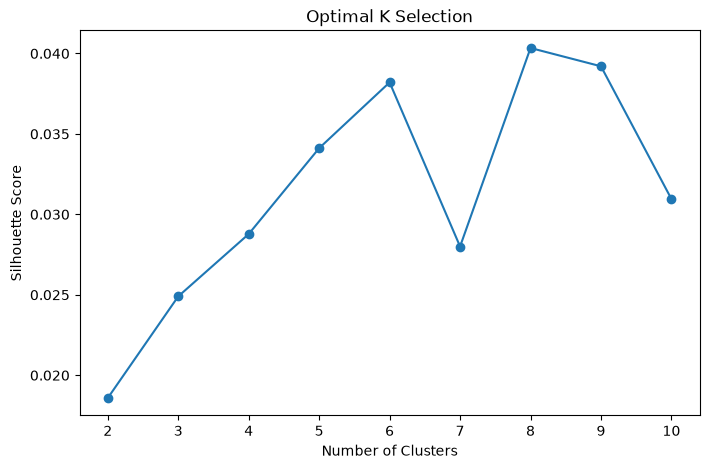


Cluster: 0
    index                                        title  release_year  score  \
0       0     David Attenborough: A Life on Our Planet          2020    9.0   
1       1                                    Inception          2010    8.8   
7       7                                       Dangal          2016    8.4   
12     12                                 Black Friday          2004    8.4   
14     14  Winter on Fire: Ukraine's Fight for Freedom          2015    8.3   
16     16                                  Taxi Driver          1976    8.3   
25     25                                      Virunga          2014    8.2   
27     27                   Bāhubali 2: The Conclusion          2017    8.2   
29     29                                   Article 15          2019    8.2   
35     35                     How to Train Your Dragon          2010    8.1   

    number_of_votes  duration   main_genre main_production  \
0             31180        83  documentary              

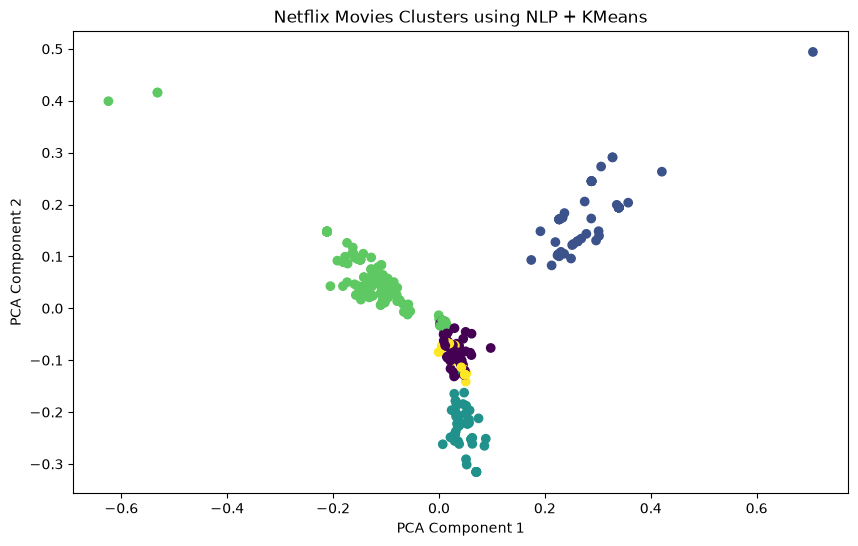

Clustering Completed Successfully!


In [1]:
# Best Movies Netflix - KMeans Clustering using NLP
# Dataset: Best Movies Netflix.csv

# ==========================================
# 1. Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import re

# Download stopwords
nltk.download('stopwords')


# ==========================================
# 2. Load Dataset
# ==========================================

df = pd.read_csv("Best Movies Netflix.csv")

# Display first rows
df.head()


# ==========================================
# 3. Explore Dataset
# ==========================================

print(df.shape)

df.info()

print(df.isnull().sum())


# ==========================================
# 4. Data Cleaning
# ==========================================

# Convert column names to lowercase
df.columns = df.columns.str.lower().str.replace(" ", "_")

df.head()


# Fill missing values
df = df.fillna("")


# Display columns
print(df.columns)


# ==========================================
# 5. Create Text Feature for NLP
# ==========================================

# Combine available text columns
text_columns = df.select_dtypes(include=['object']).columns

df["combined_text"] = df[text_columns].apply(
    lambda x: " ".join(x.astype(str)),
    axis=1
)


df[["combined_text"]].head()


# ==========================================
# 6. NLP Text Cleaning
# ==========================================

stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()


def clean_text(text):
    
    text = text.lower()
    
    # Remove special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # Tokenize
    words = text.split()
    
    # Remove stopwords and stemming
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)


df["clean_text"] = df["combined_text"].apply(clean_text)


df.head()


# ==========================================
# 7. Convert Text into TF-IDF Features
# ==========================================

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df["clean_text"])


print(X.shape)


# ==========================================
# 8. Find Optimal Number of Clusters
# ==========================================

silhouette_scores = []

K = range(2,11)


for k in K:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    
    silhouette_scores.append(score)


plt.figure(figsize=(8,5))

plt.plot(
    K,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Optimal K Selection")

plt.show()


# ==========================================
# 9. Train Final KMeans Model
# ==========================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)


df["cluster"] = kmeans.fit_predict(X)


df.head()


# ==========================================
# 10. Display Movies by Cluster
# ==========================================

for cluster in range(5):
    
    print("\n==============================")
    print("Cluster:", cluster)
    print("==============================")
    
    print(
        df[df["cluster"] == cluster]
        .head(10)
    )


# ==========================================
# 11. PCA Visualization
# ==========================================

pca = PCA(
    n_components=2,
    random_state=42
)


X_pca = pca.fit_transform(
    X.toarray()
)


plt.figure(figsize=(10,6))


plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["cluster"]
)


plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title(
    "Netflix Movies Clusters using NLP + KMeans"
)

plt.show()


# ==========================================
# 12. Save Clustered Dataset
# ==========================================

df.to_csv(
    "Netflix_Movies_KMeans_NLP_Clusters.csv",
    index=False
)


print("Clustering Completed Successfully!")